In [4]:
from langchain_groq import ChatGroq
from dotenv import find_dotenv
from dotenv import load_dotenv
# Load environment variables (ensure GROQ_API_KEY is set in your .env)
load_dotenv(find_dotenv())

# Initialize Groq model
llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.7,
)

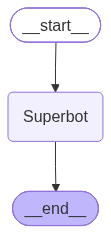

In [5]:
from langgraph.constants import END
from langgraph.constants import START
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import add_messages
from typing import Annotated
from typing import TypedDict

class State(TypedDict):
    messages : Annotated[list, add_messages]

memory = MemorySaver()

def superbot(state: State):
    return {'messages' : llm.invoke(state["messages"])}

graph = StateGraph(State)

graph.add_node("Superbot", superbot)
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer=memory)
graph_builder

In [ ]:
config = {"configurable": {"thread_id": "1"}}

for chunk in graph_builder.stream({'messages': "Hi, My name is Krish And I like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': AIMessage(content='Hi Krish! Nice to meet you.\n\nCricket is a fantastic sport with so many nuances and thrilling moments. Do you have a favorite team or player that you follow? Or are you more into the technical side of the game, like batting technique or bowling variations? I’d love to chat more about it! 🏏', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 22, 'total_tokens': 89, 'completion_time': 0.132321996, 'completion_tokens_details': None, 'prompt_time': 0.001774649, 'prompt_tokens_details': None, 'queue_time': 0.08399164, 'total_time': 0.134096645}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_4560dae850', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0af96-f09c-7053-bfe5-2d14f9b4a122-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 67, 'total_tokens': 89})}}


In [7]:
for chunk in graph_builder.stream({'messages': "I also like football"}, config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': AIMessage(content='That’s great, Krish! It’s always fun to be a fan of multiple sports. Football (soccer) has that unique global intensity and passion that matches cricket in many ways.\n\nDo you have a favorite football club or national team? And are there any specific players whose playstyle you admire? I’m curious if you lean more towards the tactical side or the excitement of the matches! ⚽', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 106, 'total_tokens': 189, 'completion_time': 0.157980764, 'completion_tokens_details': None, 'prompt_time': 0.008066975, 'prompt_tokens_details': None, 'queue_time': 0.221044723, 'total_time': 0.166047739}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0af98-efbc-7ec0-85ec-f7e10958556e-0', tool_calls=[], invalid_tool_calls=[], usage

In [8]:
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages': "Hi, My name is Arpit And I like cricket"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Arpit And I like cricket', additional_kwargs={}, response_metadata={}, id='18216add-3fad-457b-a14e-cb2c3dda75a1')]}
{'messages': [HumanMessage(content='Hi, My name is Arpit And I like cricket', additional_kwargs={}, response_metadata={}, id='18216add-3fad-457b-a14e-cb2c3dda75a1'), AIMessage(content='Hi Arpit! It’s great to meet you. 🏏\n\nCricket is a wonderful sport with so much strategy and excitement. Are you a fan of any particular team (like India, Australia, England, etc.) or any specific players? I’d love to hear what aspects of the game you enjoy the most—whether it’s the thrill of a chase, the precision of spin bowling, or the drama of the T20 format!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 23, 'total_tokens': 115, 'completion_time': 0.17755151, 'completion_tokens_details': None, 'prompt_time': 0.001581756, 'prompt_tokens_details': None, 'queue_time': 0.075953653, 'to

In [9]:
for chunk in graph_builder.stream({'messages': "I also like football"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Arpit And I like cricket', additional_kwargs={}, response_metadata={}, id='18216add-3fad-457b-a14e-cb2c3dda75a1'), AIMessage(content='Hi Arpit! It’s great to meet you. 🏏\n\nCricket is a wonderful sport with so much strategy and excitement. Are you a fan of any particular team (like India, Australia, England, etc.) or any specific players? I’d love to hear what aspects of the game you enjoy the most—whether it’s the thrill of a chase, the precision of spin bowling, or the drama of the T20 format!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 23, 'total_tokens': 115, 'completion_time': 0.17755151, 'completion_tokens_details': None, 'prompt_time': 0.001581756, 'prompt_tokens_details': None, 'queue_time': 0.075953653, 'total_time': 0.179133266}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': Non

In [10]:
config = {"configurable": {"thread_id": "3"}}
async for event in graph_builder.astream_events({"messages": ["Hi My name is Krish and I like to play cricket"]},config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0af9d-ce66-7b20-937d-55200c96b4e7', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='c7a54332-8e94-4d1a-a048-cbfeee0b3376')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '01a0af9d-ce68-74f3-bdd1-2d7004a97a7c', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:cf6a7fe8-eee8-151d-e1e0-4d588d8f6805'}, 'parent_ids': ['01a0af9d-ce66-7b20-937d-55200c96b4e7']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':